# 第1周 Day3：Transformer 宏观理解

> **学习目标**：掌握 Encoder/Decoder 结构、Multi-Head Attention
>
> **参考资源**：
> - 课程: [吴恩达 Deep Learning - Attention Mechanism](https://www.coursera.org/learn/nlp-sequence-models)
> - 课程: [李宏毅 Transformer 概述](https://www.youtube.com/watch?v=n9TlOhRjYoc)
> - 博客: [The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)
> - 论文: [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
> - 可视化: [Interactive Transformer](https://poloclub.github.io/transformer-explainer/)

---

## 📋 环境准备（首次运行请先执行下方单元格）

In [14]:
import sys
print(f"Python 版本: {sys.version}")
print(f"Python 路径: {sys.executable}")

required = {'numpy', 'torch', 'matplotlib', 'ipykernel'}
installed = set()
missing = set()

for pkg in required:
    try:
        __import__(pkg)
        installed.add(pkg)
    except ImportError:
        missing.add(pkg)

print(f"\n已安装: {installed}")
if missing:
    print(f"缺少: {missing}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + list(missing))
    print("安装完成！请重启内核后继续。")
else:
    print("所有依赖已就绪！")
    import numpy as np
    import torch
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.font_manager import FontProperties
    print(f"  numpy: {np.__version__}")
    print(f"  torch: {torch.__version__}")

    # ==== 配置matplotlib中文字体 ====
    chinese_fonts = ['Microsoft YaHei', 'SimHei', 'SimSun', 'FangSong',
                    'KaiTi', 'STSong', 'STHeiti', 'STFangsong']

    available_fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
    selected_font = None

    for font_name in chinese_fonts:
        if font_name in available_fonts:
            selected_font = font_name
            break

    if selected_font:
        plt.rcParams['font.sans-serif'] = [selected_font]
        plt.rcParams['axes.unicode_minus'] = False
        # 配置数学公式字体，避免公式中特殊字符显示为方块
        plt.rcParams['mathtext.fontset'] = 'dejavusans'  # 数学公式用 DejaVu 字体
        plt.rcParams['mathtext.default'] = 'regular'    # 数学公式用常规字重
        print(f"  matplotlib: {matplotlib.__version__}")
        print(f"  中文字体: {selected_font}")
        print(f"  数学字体: DejaVu Sans")
    else:
        print(f"  matplotlib: {matplotlib.__version__}")
        print(f"  ⚠ 警告: 未找到中文字体，中文可能显示为方块")
        print(f"  可用字体: {available_fonts[:10]}...")

Python 版本: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python 路径: c:\Users\WenhaoZou\.conda\envs\dl\python.exe

已安装: {'torch', 'matplotlib', 'numpy', 'ipykernel'}
所有依赖已就绪！
  numpy: 2.4.6
  torch: 2.12.1+cu126
  matplotlib: 3.11.0
  中文字体: Microsoft YaHei
  数学字体: DejaVu Sans


---

## 第一部分：Transformer 的诞生背景

### 1.1 为什么需要 Transformer？—— RNN 的困境

在 Transformer 之前，主流的序列模型是 RNN/LSTM。让我们先理解它们的问题：

**RNN 的工作方式**：
```
RNN 架构（机器翻译为例）：
  输入: "I love AI"
  
  步骤1: 读取 "I"   → 更新隐藏状态 h1
  步骤2: 读取 "love" → 更新隐藏状态 h2（依赖 h1）
  步骤3: 读取 "AI"   → 更新隐藏状态 h3（依赖 h2）
  ...
  输出: "我爱AI"
```

**RNN 的三大致命问题**：

| 问题 | 说明 | 后果 |
|------|------|------|
| ❌ 串行计算 | 必须等前一个词处理完才能处理下一个 | GPU 并行化效率极低 |
| ❌ 长距离依赖 | 信息要穿越很多时间步才能传递 | 早期信息被稀释/遗忘 |
| ❌ 梯度消失 | 链式法则导致梯度指数级衰减 | 难以训练长句子 |

**💡 形象的例子**：
想象你要翻译一句话 "The cat which lives in the big house that was built..."，RNN 需要记住最开头的 "cat" 信息，穿越几十个单词才能在 "was built" 相关的地方用到它，这时候信息早就模糊了。

**CNN 作为替代方案**：
- CNN 可以并行计算
- 但卷积核的感受野是局部的
- 要让相距很远的词交互，需要堆很多层

### 1.2 Transformer 的革命性突破

2017 年，Google 在论文《Attention Is All You Need》中提出了 Transformer：

**核心思想**：既然 Attention 机制可以让模型直接关注任意位置的信息，那为什么要依赖 RNN 或 CNN 呢？

**Transformer 的三大创新**：

| 创新 | 说明 | 优势 |
|------|------|------|
| ✅ Self-Attention | 任意两个位置直接交互 | 并行 + 长距离依赖 |
| ✅ 完全并行 | 一次处理整个序列 | GPU 友好，训练快 |
| ✅ 位置编码 | 用数学公式注入位置 | 不需要 RNN |

**💡 为什么叫 "Attention Is All You Need"？**
论文标题的含义是：在序列到序列任务中，仅靠注意力机制就足够了，不需要 RNN 或 CNN。

### 1.3 Transformer 整体架构一览

```
┌─────────────────────────────────────────────────────────────────────┐
│                        Transformer 完整架构                          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   源序列: "I love AI"                                              │
│           ↓                                                         │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │  Input Embedding + Positional Encoding                      │   │
│   └─────────────────────────────────────────────────────────────┘   │
│           ↓                                                         │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │                      Encoder Stack                          │   │
│   │              (N = 6 个 Encoder Layer)                       │   │
│   └─────────────────────────────────────────────────────────────┘   │
│           ↓                                                         │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │                      Decoder Stack                          │   │
│   │              (N = 6 个 Decoder Layer)                       │   │
│   └─────────────────────────────────────────────────────────────┘   │
│           ↓                                                         │
│   Linear + Softmax → 概率分布 → "我爱AI"                           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Encoder vs Decoder 的区别**（理解这个很重要！）：

| | Encoder（编码器） | Decoder（解码器） |
|---|---|---|
| **任务** | 理解输入序列 | 生成输出序列 |
| **注意力** | 双向注意力（看全文） | 因果注意力（只看左边） |
| **典型模型** | BERT | GPT |
| **应用场景** | 分类、NER、问答 | 文本生成、翻译 |

**💡 形象理解**：
- Encoder 像是**阅读理解**：看完整篇文章，理解每个词的含义
- Decoder 像是**写作**：一个字一个字生成，写的时候只能看之前写的

---

## 第二部分：位置编码（Positional Encoding）

### 2.1 为什么需要位置编码？

**关键问题**：Self-Attention 本身不包含位置信息！

看一个例子：
```
句子1: "狗狗咬了猫咪" → [狗, 咬, 了, 猫, 猫]
句子2: "猫咪咬了狗狗" → [猫, 咬, 了, 狗, 狗]

如果只用 Embedding，不加位置信息：
- "狗狗咬了猫咪" 和 "猫咪咬了狗狗" 的表示可能完全相同！
- 因为 Self-Attention 只关心词与词之间的关系，不关心顺序
```

**RNN 的优点**：天然包含位置信息，因为是顺序处理的
**Transformer 的解决方案**：用数学公式显式地加入位置信息

### 2.2 位置编码的数学公式

论文中使用的位置编码公式（基于三角函数）：

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

其中：
- $pos$ = 词在序列中的位置（0, 1, 2, ...）
- $i$ = 维度索引（0, 1, 2, ..., $d_{model}-1$）
- $d_{model}$ = 词向量的维度

**💡 为什么用正弦和余弦交替？**
1. **表示相对位置**：$\sin(pos + k)$ 和 $\cos(pos + k)$ 可以表示
2. **不需要学习**：直接计算，适用于任意长度的序列
3. **周期性**：不同频率可以表示不同尺度的位置关系

位置编码可视化


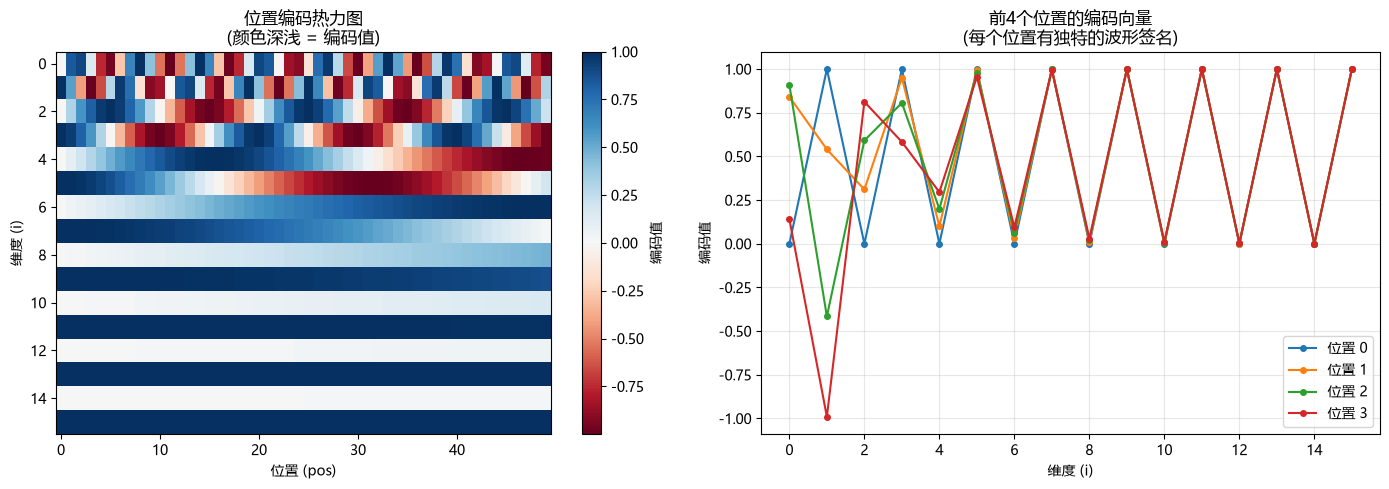


位置编码形状: (50, 16)

位置0的编码（前10维）: [0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]
位置1的编码（前10维）: [0.8415 0.5403 0.311  0.9504 0.0998 0.995  0.0316 0.9995 0.01   1.    ]
位置10的编码（前10维）: [-0.544  -0.8391 -0.0207 -0.9998  0.8415  0.5403  0.311   0.9504  0.0998
  0.995 ]

💡 位置编码的特点：
  位置10的编码 ≠ 位置0的编码 + 位置1的编码
  但通过三角公式，可以推导出相对位置关系


In [15]:
# 实现位置编码
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_seq_len, d_model):
    """
    计算位置编码

    参数:
        max_seq_len: 最大序列长度
        d_model: 模型维度（词向量维度）

    返回:
        PE: (max_seq_len, d_model) 位置编码矩阵
    """
    PE = np.zeros((max_seq_len, d_model))

    for pos in range(max_seq_len):
        for i in range(0, d_model, 2):
            # 偶数维度用 sin
            PE[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
            # 奇数维度用 cos
            if i + 1 < d_model:
                PE[pos, i + 1] = np.cos(pos / (10000 ** (i / d_model)))

    return PE

# 可视化位置编码
max_seq_len = 50
d_model = 16
PE = positional_encoding(max_seq_len, d_model)

print("=" * 60)
print("位置编码可视化")
print("=" * 60)

# 绘制热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 热力图 - 直观看出位置差异
im = axes[0].imshow(PE.T, aspect='auto', cmap='RdBu')
axes[0].set_title('位置编码热力图\n(颜色深浅 = 编码值)', fontsize=12)
axes[0].set_xlabel('位置 (pos)', fontsize=10)
axes[0].set_ylabel('维度 (i)', fontsize=10)
plt.colorbar(im, ax=axes[0], label='编码值')

# 曲线图 - 看我个位置的唯一"签名"
for pos in range(4):
    axes[1].plot(PE[pos], 'o-', label=f'位置 {pos}', markersize=4)
axes[1].set_title('前4个位置的编码向量\n(每个位置有独特的波形签名)', fontsize=12)
axes[1].set_xlabel('维度 (i)', fontsize=10)
axes[1].set_ylabel('编码值', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n位置编码形状: {PE.shape}")
print(f"\n位置0的编码（前10维）: {PE[0, :10].round(4)}")
print(f"位置1的编码（前10维）: {PE[1, :10].round(4)}")
print(f"位置10的编码（前10维）: {PE[10, :10].round(4)}")

# 验证：位置10和位置0+10的关系
print("\n💡 位置编码的特点：")
print(f"  位置10的编码 ≠ 位置0的编码 + 位置1的编码")
print(f"  但通过三角公式，可以推导出相对位置关系")

### 2.3 位置编码的直观理解

**💡 位置编码的关键性质**：

1. **每个位置都有独特的"签名"**：像身份证号一样，每个位置的编码向量都是不同的

2. **位置关系可计算**：
   - $\sin(A + B)$ 和 $\cos(A + B)$ 可以表达 $A$ 和 $B$ 的相对位置
   - 这对 Transformer 很重要，因为它能学习到 "位置 5 的词和位置 3 的词关系更密切"

3. **为什么用 $10000^{2i/d}$ 做分母？**
   - 当 $i$ 小时，频率高（周期短），能表示精细的位置差异
   - 当 $i$ 大时，频率低（周期长），能表示宏观的位置关系
   - 就像音乐：从低频（bass）到高频（treble）

---

## 第三部分：Self-Attention（自注意力机制）⭐⭐⭐

### 3.1 Attention 机制的灵魂三问

**Attention 机制回答三个问题**：

| 问题 | 比喻 | 在翻译中的应用 |
|------|------|----------------|
| **Query: 我要找什么？** | 搜索框 | 要翻译的当前词 |
| **Key: 我有哪些信息？** | 商品标签 | 输入句子的每个词 |
| **Value: 信息内容是什么？** | 商品详情 | 词的实际含义 |

**💡 图书馆的比喻**（李宏毅老师课程）：
```
想象你去图书馆找书：

Query（查询）= 你想找的书名关键词
Key（键）    = 图书馆每本书的书名
Value（值）  = 每本书的内容简介

Attention 过程：
1. 用 Query 匹配 Key（书名匹配）
2. 得到匹配分数（相似度）
3. Softmax 转成概率
4. 用概率加权 Value，得到最终结果
```

### 3.2 Self-Attention 的数学公式

**核心公式**（来自吴恩达课程）：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**逐步拆解**：

**Step 1: 计算 Q, K, V**
$$Q = X \cdot W_Q$$
$$K = X \cdot W_K$$
$$V = X \cdot W_V$$

- $X$ 是输入序列的词向量
- $W_Q, W_K, W_V$ 是可学习的权重矩阵
- $Q, K, V$ 的每一行代表一个词的 Query/Key/Value

**Step 2: 计算相似度分数**
$$\text{scores} = Q \cdot K^T$$

- 这是点积运算，衡量每对 (Query, Key) 的相似度
- 结果是一个矩阵：第 $i$ 行第 $j$ 列表示"位置 $i$ 的词应该多关注位置 $j$ 的词"

**Step 3: Scale（缩放）**
$$\text{scores}_{scaled} = \frac{\text{scores}}{\sqrt{d_k}}$$

**💡 为什么需要除以 $\sqrt{d_k}$？**（这是面试常考题！）

当 $d_k$ 很大时，$QK^T$ 的值会很大，导致 softmax 后梯度变小（类似梯度消失）
除以 $\sqrt{d_k}$ 可以让点积的方差稳定在 1 左右

**Step 4: Softmax**
$$\text{attention\_weights} = \text{softmax}(\text{scores}_{scaled})$$

- 把分数转成概率分布（每行和为 1）
- 概率越大表示越关注那个位置

**Step 5: 加权求和**
$$\text{output} = \text{attention\_weights} \cdot V$$

- 用注意力权重对 Value 加权求和
- 得到的就是融合了上下文信息的词表示

Scaled Dot-Product Attention 详解

【输入】
Q 形状: torch.Size([1, 1, 4, 3])  (seq_len=4, d_k=3)
K 形状: torch.Size([1, 1, 4, 3])
V 形状: torch.Size([1, 1, 4, 3])

【输出】
注意力输出形状: torch.Size([1, 1, 4, 3])
注意力权重形状: torch.Size([1, 1, 4, 4])  (4x4矩阵)


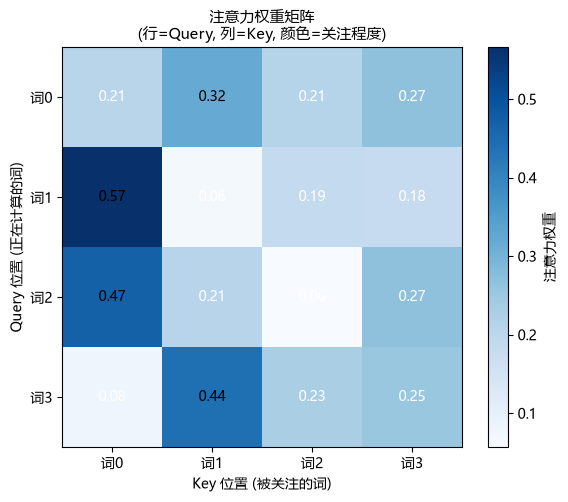


【注意力权重矩阵解读】
  第0行: '词0' 对所有词的注意力分布（应该关注谁？）
  第1行: '词1' 对所有词的注意力分布
  第2行: '词2' 对所有词的注意力分布
  第3行: '词3' 对所有词的注意力分布

  每行加起来 = 1.0（softmax 的效果）


In [16]:
# 实现 Scaled Dot-Product Attention（PyTorch 版本）
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    计算 Scaled Dot-Product Attention

    参数:
        Q: Query 向量 (batch, num_heads, seq_len, d_k)
        K: Key 向量   (batch, num_heads, seq_len, d_k)
        V: Value 向量 (batch, num_heads, seq_len, d_v)
        mask: 掩码（可选，用于因果掩码或填充掩码）

    返回:
        output: 注意力输出    (batch, num_heads, seq_len, d_v)
        attention_weights: 注意力权重 (batch, num_heads, seq_len, seq_len)
    """
    d_k = Q.size(-1)  # Query 向量维度

    # Step 1: 计算点积相似度
    # Q @ K^T : (batch, heads, seq_len, d_k) @ (batch, heads, d_k, seq_len)
    #         -> (batch, heads, seq_len, seq_len)
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # Step 2: Scale
    scores_scaled = scores / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

    # Step 3: 可选：应用掩码
    if mask is not None:
        scores_scaled = scores_scaled.masked_fill(mask == 0, float('-inf'))

    # Step 4: Softmax
    attention_weights = F.softmax(scores_scaled, dim=-1)

    # Step 5: 加权求和
    output = torch.matmul(attention_weights, V)

    return output, attention_weights


# ===== 演示：用具体数字理解 Attention =====
print("=" * 60)
print("Scaled Dot-Product Attention 详解")
print("=" * 60)

# 简单示例：4个词，d_k = 3
seq_len = 4
d_k = 3

# 固定随机种子，便于理解
torch.manual_seed(42)

# 假设这是 4 个词的 Query 向量
Q = torch.randn(1, 1, seq_len, d_k)  # (batch=1, heads=1, seq_len=4, d_k=3)
K = torch.randn(1, 1, seq_len, d_k)
V = torch.randn(1, 1, seq_len, d_k)

print(f"\n【输入】")
print(f"Q 形状: {Q.shape}  (seq_len=4, d_k=3)")
print(f"K 形状: {K.shape}")
print(f"V 形状: {V.shape}")

# 计算注意力
output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"\n【输出】")
print(f"注意力输出形状: {output.shape}")
print(f"注意力权重形状: {attn_weights.shape}  (4x4矩阵)")

# 可视化注意力权重矩阵
attn_np = attn_weights.squeeze().detach().numpy()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_np, cmap='Blues')
ax.set_title('注意力权重矩阵\n(行=Query, 列=Key, 颜色=关注程度)', fontsize=11)
ax.set_xlabel('Key 位置 (被关注的词)')
ax.set_ylabel('Query 位置 (正在计算的词)')
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels([f'词{i}' for i in range(seq_len)])
ax.set_yticklabels([f'词{i}' for i in range(seq_len)])
plt.colorbar(im, label='注意力权重')

# 在每个格子上标注数值
for i in range(seq_len):
    for j in range(seq_len):
        text = ax.text(j, i, f'{attn_np[i, j]:.2f}',
                       ha='center', va='center', color='black' if attn_np[i, j] > 0.3 else 'white')
plt.tight_layout()
plt.show()

print(f"\n【注意力权重矩阵解读】")
print(f"  第0行: '词0' 对所有词的注意力分布（应该关注谁？）")
print(f"  第1行: '词1' 对所有词的注意力分布")
print(f"  第2行: '词2' 对所有词的注意力分布")
print(f"  第3行: '词3' 对所有词的注意力分布")
print(f"\n  每行加起来 = 1.0（softmax 的效果）")

### 3.3 Self-Attention 的直观理解

**💡 举例说明**（来自吴恩达课程）：

假设要翻译这句话：
```
英文: "The animal didn't cross the street because it was too tired"
中文: "动物没有过马路，因为它太累了"
```

**问题**：`"it"` 指的是什么？

在 Self-Attention 中：
- `"it"` 的 Query 会与所有词的 Key 计算相似度
- `"animal"` 的 Key 与 `"it"` 的 Query 相似度最高
- 所以 `"it"` 的输出会大量融合 `"animal"` 的信息

**这就是 Attention 解决"代词指代"问题的原理！**

```
Attention 权重可视化：

       The  animal didn\'t  cross  the  street  because  it  was  too  tired
it    [ 0.02   0.65    0.01   0.01   0.02   0.01    0.01   0.95  0.02  0.01  0.01]
                ↑                                           ↑
              animal                                      self
```

### 3.4 为什么需要 Scale？（面试常考）

**问题**：为什么要除以 $\sqrt{d_k}$？

**直觉解释**：

假设 $q$ 和 $k$ 的每个分量都是独立随机变量，均值为 0，方差为 1

那么 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ 的：
- 均值 = 0
- 方差 = $d_k$（因为 $d_k$ 个独立随机变量相加）

**当 $d_k$ 很大时，方差会很大，导致点积的值域范围很大**

举例：
```
d_k = 64 时，点积的值可能达到几百
d_k = 512 时，点积的值可能达到几千
```

**大问题**：这些大值经过 softmax 会变得非常"尖锐"
```
softmax([100, 200, 300]) ≈ [0.0, 0.0, 1.0]  # 几乎变成 one-hot
softmax([0.1, 0.2, 0.3])  ≈ [0.3, 0.3, 0.4]  # 平滑分布
```

**结果**：梯度接近 0，模型难以训练

**解决方案**：除以 $\sqrt{d_k}$，让方差稳定在 1

**💡 记忆口诀**：大 d_k 要 Scale，否则 Attention 变 one-hot

---

## 第四部分：Multi-Head Attention（多头注意力）

### 4.1 为什么需要多个头？

**问题**：一个 Attention 头够用吗？

**答案**：不够！因为语言是复杂的多义系统

**例子**（李宏毅老师课程）：
```
句子: "The bank is near the river"

在翻译成中文时，"bank" 应该翻译成：
- "银行"（金融机构含义）
- "河岸"（地理含义）

不同的头可以关注不同的语义关系：
- Head 1: 关注"bank"和"river"的关系 → "河岸"
- Head 2: 关注"bank"和"financial"的关系 → "银行"
```

**形象理解**：
就像人类的脑子有不同的区域处理不同信息：
- 视觉皮层处理图像
- 语言皮层处理语法
- 记忆区处理关联

Multi-Head 让 Transformer 能同时学习多种类型的关系！

### 4.2 Multi-Head Attention 的结构

```
Multi-Head Attention 流程：

输入 X (seq_len, d_model)
    ↓
┌──────────────────────────────────────────────────────────┐
│  Linear 变换生成 Q, K, V                                  │
└──────────────────────────────────────────────────────────┘
    ↓
┌──────────────────────────────────────────────────────────┐
│  Split into h heads                                      │
│                                                          │
│  Head 1: Q1, K1, V1 → Attention → O1                    │
│  Head 2: Q2, K2, V2 → Attention → O2                    │
│  ...                                                    │
│  Head h: Qh, Kh, Vh → Attention → Oh                   │
└──────────────────────────────────────────────────────────┘
    ↓
┌──────────────────────────────────────────────────────────┐
│  Concatenate: O1 ⊕ O2 ⊕ ... ⊕ Oh                       │
└──────────────────────────────────────────────────────────┘
    ↓
┌──────────────────────────────────────────────────────────┐
│  Final Linear: W_O @ Concat                             │
└──────────────────────────────────────────────────────────┘
    ↓
输出

数学公式：
MultiHead(Q, K, V) = Concat(head_1, ..., head_h) W_O
其中 head_i = Attention(Q W_Q^i, K W_K^i, V W_V^i)
```

Multi-Head Attention 演示

【输入】
  X 形状: torch.Size([2, 10, 256])

【参数】
  d_model = 256
  num_heads = 8
  d_k (每头维度) = 32

【输出】
  output 形状: torch.Size([2, 10, 256])  (保持 d_model 不变)
  attention_weights 形状: torch.Size([2, 8, 10, 10])
     - batch=2
     - heads=8
     - seq_len=10 x 10


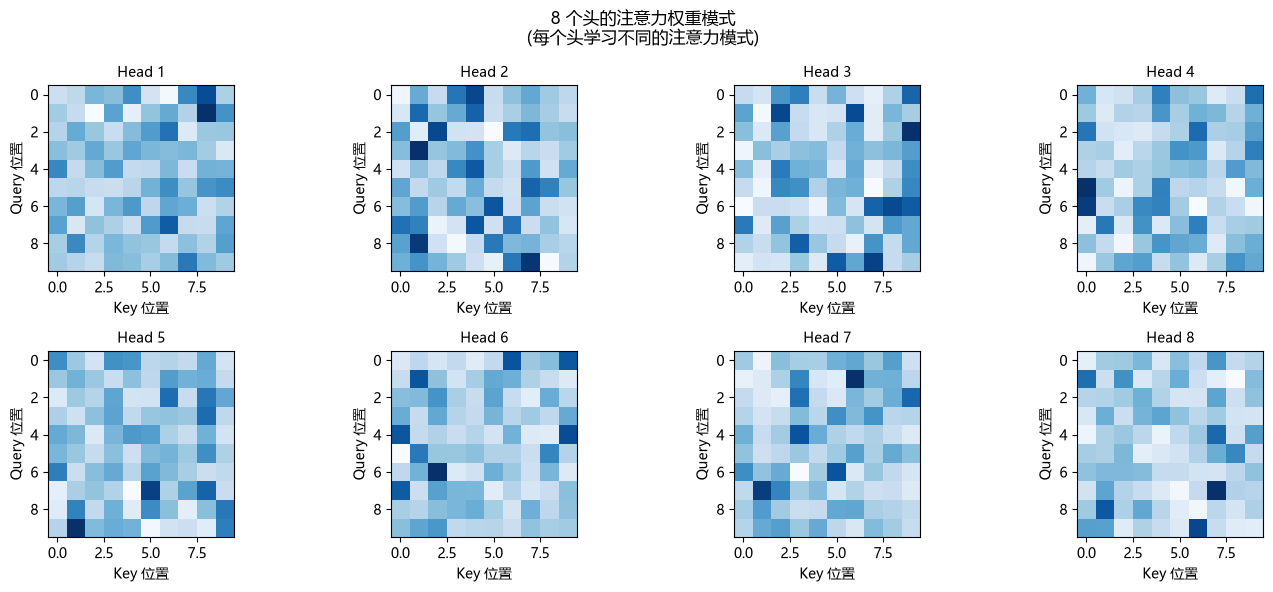


💡 观察：不同头的注意力模式是不同的！
   - 有的头可能关注相邻词
   - 有的头可能关注远距离词
   - 这让模型能同时学习多种关系


In [17]:
# 实现 Multi-Head Attention
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        初始化 Multi-Head Attention

        参数:
            d_model: 模型的维度（词向量维度）
            num_heads: 注意力头的数量
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度

        # 定义 Q, K, V 的线性变换
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        """
        将批次数据拆分成多个头

        参数:
            x: (batch, seq_len, d_model)

        返回:
            (batch, num_heads, seq_len, d_k)
        """
        batch_size = x.size(0)
        # reshape: (batch, seq_len, d_model) -> (batch, seq_len, num_heads, d_k)
        # 然后 transpose: -> (batch, num_heads, seq_len, d_k)
        return x.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, Q, K, V, mask=None):
        """
        前向传播

        参数:
            Q: (batch, seq_len, d_model)
            K: (batch, seq_len, d_model)
            V: (batch, seq_len, d_model)
            mask: 掩码（可选）

        返回:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, num_heads, seq_len, seq_len)
        """
        batch_size = Q.size(0)

        # Step 1: 线性变换
        Q = self.W_Q(Q)  # (batch, seq_len, d_model)
        K = self.W_K(K)
        V = self.W_V(V)

        # Step 2: 拆分多头
        Q = self.split_heads(Q)  # (batch, num_heads, seq_len, d_k)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Step 3: 计算注意力
        output, attention_weights = scaled_dot_product_attention(Q, K, V, mask)

        # Step 4: 合并多头
        # output: (batch, num_heads, seq_len, d_k) -> (batch, seq_len, d_model)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # Step 5: 最终线性变换
        output = self.W_O(output)

        return output, attention_weights


# ===== 演示 Multi-Head Attention =====
print("=" * 60)
print("Multi-Head Attention 演示")
print("=" * 60)

# 参数设置
d_model = 256      # 模型维度
num_heads = 8      # 8 个头
batch_size = 2
seq_len = 10

mha = MultiHeadAttention(d_model, num_heads)
X = torch.randn(batch_size, seq_len, d_model)

output, attn_weights = mha(X, X, X)

print(f"\n【输入】")
print(f"  X 形状: {X.shape}")
print(f"\n【参数】")
print(f"  d_model = {d_model}")
print(f"  num_heads = {num_heads}")
print(f"  d_k (每头维度) = {d_model // num_heads}")
print(f"\n【输出】")
print(f"  output 形状: {output.shape}  (保持 d_model 不变)")
print(f"  attention_weights 形状: {attn_weights.shape}")
print(f"     - batch={attn_weights.shape[0]}")
print(f"     - heads={attn_weights.shape[1]}")
print(f"     - seq_len={attn_weights.shape[2]} x {attn_weights.shape[3]}")

# 可视化不同头的注意力模式
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

attn_vis = attn_weights[0].detach().numpy()  # 取第一个 batch

for head_idx in range(8):
    ax = axes[head_idx]
    im = ax.imshow(attn_vis[head_idx], cmap='Blues')
    ax.set_title(f'Head {head_idx + 1}', fontsize=10)
    ax.set_xlabel('Key 位置')
    ax.set_ylabel('Query 位置')
plt.suptitle('8 个头的注意力权重模式\n(每个头学习不同的注意力模式)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n💡 观察：不同头的注意力模式是不同的！")
print(f"   - 有的头可能关注相邻词")
print(f"   - 有的头可能关注远距离词")
print(f"   - 这让模型能同时学习多种关系")

---

## 第五部分：Encoder Layer（编码器层）

### 5.1 Encoder Layer 的结构

每个 Encoder Layer 包含两个子层：

```
Encoder Layer 结构：

输入 X
    ↓
┌───────────────────────────────────────┐
│  Sublayer 1: Multi-Head Self-Attention │
│  （每个词可以和所有词交互）             │
└───────────────────────────────────────┘
    ↓
┌───────────────────────────────────────┐
│  Add & Norm 1                         │
│  残差连接 + Layer Normalization        │
└───────────────────────────────────────┘
    ↓
┌───────────────────────────────────────┐
│  Sublayer 2: Feed-Forward Network     │
│  两个线性变换 + ReLU                   │
│  Linear → ReLU → Linear               │
└───────────────────────────────────────┘
    ↓
┌───────────────────────────────────────┐
│  Add & Norm 2                         │
│  残差连接 + Layer Normalization        │
└───────────────────────────────────────┘
    ↓
输出
```

### 5.2 残差连接（Residual Connection）

**💡 什么是残差连接？**

残差连接的公式：$\text{output} = x + \mathcal{F}(x)$

即：**原始输入 + 变换后的输出**

**为什么需要残差连接？**

| 问题 | 残差连接的解决方案 |
|------|---------------------|
| 深层网络梯度消失 | 梯度有"高速公路"直接传到底层 |
| 信息衰减 | 原始信息无损传递到深层 |
| 训练困难 | 每层只需学习"残差"，降低学习难度 |

**形象的例子**：
```
你要从 1 楼爬到 5 楼：

普通网络：每层都要记住完整楼层信息
残差网络：每层只需记住"再往上爬一层"

残差让信息直接从 1 楼流到 5 楼！
```

### 5.3 Layer Normalization（层归一化）

**Layer Norm vs Batch Norm**：

| | Layer Norm | Batch Norm |
|---|---|---|
| 归一化维度 | 同一个样本的所有维度 | 不同样本的同一个维度 |
| 适用场景 | 序列模型、Transformer | 图像分类、CNN |
| 公式 | $\frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$ | 同 |

**Transformer 中为什么用 Layer Norm？**

1. **序列长度可能变化**：不同句子的长度不同，Batch Norm 不稳定
2. **RNN-style 依赖**：Layer Norm 更适合序列模型
3. **训练和推理一致**：Batch Norm 在推理时需要统计全局均值方差

**💡 Layer Norm 计算方式**（以单个向量为例）：
```
假设一个词的向量是 [0.5, -1.2, 0.8, -0.3]

均值 μ = (0.5 - 1.2 + 0.8 - 0.3) / 4 = -0.05
方差 σ² = [(0.5+0.05)² + (-1.2+0.05)² + (0.8+0.05)² + (-0.3+0.05)²] / 4

归一化: (x - μ) / √(σ² + ε)
```

In [18]:
# 实现 Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        """
        初始化 Encoder Layer

        参数:
            d_model: 模型维度
            num_heads: 注意力头数
            d_ff: Feed-Forward 隐藏层维度（通常 4 * d_model）
            dropout: Dropout 比率
        """
        super().__init__()

        # Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, num_heads)

        # Feed-Forward Network
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        前向传播

        参数:
            x: (batch, seq_len, d_model)
            mask: 掩码（用于填充 token）

        返回:
            output: (batch, seq_len, d_model)
        """
        # ===== Sublayer 1: Self-Attention + Add & Norm =====
        # Self-Attention
        attn_output, _ = self.self_attn(x, x, x, mask)
        # Add（残差连接）
        x = x + self.dropout(attn_output)
        # Norm（层归一化）
        x = self.norm1(x)

        # ===== Sublayer 2: Feed-Forward + Add & Norm =====
        # Feed-Forward
        ff_output = self.feed_forward(x)
        # Add（残差连接）
        x = x + self.dropout(ff_output)
        # Norm（层归一化）
        x = self.norm2(x)

        return x


# ===== 演示 Encoder Layer =====
print("=" * 60)
print("Encoder Layer 演示")
print("=" * 60)

# 参数设置
d_model = 128
num_heads = 4
d_ff = 512  # 通常是 d_model 的 4 倍
batch_size = 2
seq_len = 10

encoder_layer = EncoderLayer(d_model, num_heads, d_ff)

# 模拟输入
X = torch.randn(batch_size, seq_len, d_model)

# 前向传播
output = encoder_layer(X)

print(f"\n【输入】")
print(f"  X 形状: {X.shape}")
print(f"\n【参数】")
print(f"  d_model = {d_model}")
print(f"  num_heads = {num_heads}")
print(f"  d_ff = {d_ff} (Feed-Forward 维度)")
print(f"\n【输出】")
print(f"  output 形状: {output.shape}")
print(f"\n【子层结构】")
print(f"  1. Multi-Head Self-Attention: {d_model} -> {d_model}")
print(f"  2. Feed-Forward: {d_model} -> {d_ff} -> {d_model}")
print(f"\n【参数量】")
print(f"  总参数: {sum(p.numel() for p in encoder_layer.parameters()):,}")

Encoder Layer 演示

【输入】
  X 形状: torch.Size([2, 10, 128])

【参数】
  d_model = 128
  num_heads = 4
  d_ff = 512 (Feed-Forward 维度)

【输出】
  output 形状: torch.Size([2, 10, 128])

【子层结构】
  1. Multi-Head Self-Attention: 128 -> 128
  2. Feed-Forward: 128 -> 512 -> 128

【参数量】
  总参数: 198,272


---

## 第六部分：Decoder Layer（解码器层）

### 6.1 Decoder vs Encoder 的关键区别

Decoder 比 Encoder 多一个子层！

```
Encoder Layer vs Decoder Layer 对比：

┌─────────────────────┐     ┌─────────────────────────────┐
│    Encoder Layer    │     │       Decoder Layer         │
├─────────────────────┤     ├─────────────────────────────┤
│ Self-Attention      │     │ Masked Self-Attention      │
│ (双向，看全文)       │     │ (单向，只能看左边)           │
├─────────────────────┤     ├─────────────────────────────┤
│ Add & Norm          │     │ Add & Norm                  │
├─────────────────────┤     ├─────────────────────────────┤
│ Feed-Forward        │     │ Cross-Attention             │
│                     │     │ (Query来自Decoder，K,V来自  │
│                     │     │ Encoder)                    │
├─────────────────────┤     ├─────────────────────────────┤
│ Add & Norm          │     │ Add & Norm                  │
├─────────────────────┤     ├─────────────────────────────┤
│                     │     │ Feed-Forward                │
│                     │     ├─────────────────────────────┤
│                     │     │ Add & Norm                  │
└─────────────────────┘     └─────────────────────────────┘
```

**为什么 Decoder 需要 Masked Self-Attention？**

因为 Decoder 是**自回归**生成：
- 生成第 1 个词时，只能看到输入
- 生成第 2 个词时，只能看到"第 1 个词 + 输入"
- 生成第 3 个词时，只能看到"第 1、2 个词 + 输入"
- ...

**💡 面试常考：为什么不可以用双向注意力？**
因为在推理时，输出是未知的！你不能"先知道答案再生成答案"。

因果掩码（Causal Mask）演示

因果掩码（seq_len=5）：
  True = 可以关注，False = 不能关注

tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)

【解读】
  第 0 行：词 0 只能看词 0
  第 1 行：词 1 只能看词 0、1
  第 2 行：词 2 只能看词 0、1、2
  ...
  第 4 行：词 4 可以看所有前面的词


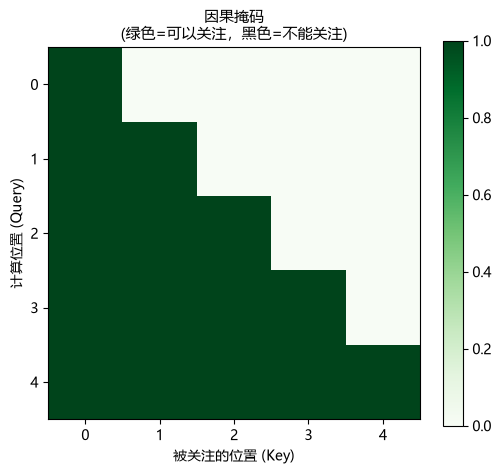

In [19]:
# 实现 Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # Masked Self-Attention（只能看左边）
        self.self_attn = MultiHeadAttention(d_model, num_heads)

        # Cross-Attention（Encoder-Decoder Attention）
        self.cross_attn = MultiHeadAttention(d_model, num_heads)

        # Feed-Forward Network
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """
        Decoder 前向传播

        参数:
            x: Decoder 输入 (batch, tgt_seq_len, d_model)
            encoder_output: Encoder 输出 (batch, src_seq_len, d_model)
            src_mask: 源序列掩码（填充掩码）
            tgt_mask: 目标序列掩码（因果掩码）
        """
        # ===== Sublayer 1: Masked Self-Attention + Add & Norm =====
        # 注意：使用 tgt_mask 防止看到未来
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = x + self.dropout(attn_output)
        x = self.norm1(x)

        # ===== Sublayer 2: Cross-Attention + Add & Norm =====
        # Q 来自 Decoder，K 和 V 来自 Encoder
        cross_output, _ = self.cross_attn(x, encoder_output, encoder_output, src_mask)
        x = x + self.dropout(cross_output)
        x = self.norm2(x)

        # ===== Sublayer 3: Feed-Forward + Add & Norm =====
        ff_output = self.feed_forward(x)
        x = x + self.dropout(ff_output)
        x = self.norm3(x)

        return x


# ===== 演示因果掩码（Causal Mask）=====
print("=" * 60)
print("因果掩码（Causal Mask）演示")
print("=" * 60)

def create_causal_mask(seq_len):
    """
    创建因果掩码

    掩码形状: (seq_len, seq_len)
    掩码为 1 的位置表示"可以关注"
    掩码为 0 的位置表示"不能关注"
    """
    # 上三角为 0（不能看未来），下三角为 1（可以看过去）
    mask = torch.tril(torch.ones(seq_len, seq_len)).bool()
    return mask

seq_len = 5
causal_mask = create_causal_mask(seq_len)

print(f"\n因果掩码（seq_len={seq_len}）：")
print(f"  True = 可以关注，False = 不能关注\n")
print(causal_mask.int())  # 显示 1/0

print(f"\n【解读】")
print(f"  第 0 行：词 0 只能看词 0")
print(f"  第 1 行：词 1 只能看词 0、1")
print(f"  第 2 行：词 2 只能看词 0、1、2")
print(f"  ...")
print(f"  第 {seq_len-1} 行：词 {seq_len-1} 可以看所有前面的词")

# 可视化
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(causal_mask.int().numpy(), cmap='Greens')
ax.set_title('因果掩码\n(绿色=可以关注，黑色=不能关注)', fontsize=11)
ax.set_xlabel('被关注的位置 (Key)')
ax.set_ylabel('计算位置 (Query)')
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
plt.colorbar(im)
plt.show()

### 6.2 Cross-Attention（交叉注意力）详解

**Cross-Attention 是 Decoder 关注 Encoder 输出的机制**

**与 Self-Attention 的区别**：

| | Self-Attention | Cross-Attention |
|---|---|---|
| Q 来自 | 同一个序列 | Decoder |
| K, V 来自 | 同一个序列 | Encoder |
| 作用 | 序列内部交互 | Decoder 关注 Encoder |

**💡 机器翻译的例子**：
```
源序列（英文）: "I love AI"  → Encoder 输出
目标序列（中文）: "我爱AI"      → Decoder 输入

当 Decoder 生成 "爱" 时：
- Query = "爱" 的表示
- Key, Value = Encoder 输出（"I", "love", "AI" 的表示）
- Cross-Attention 计算 "爱" 应该多关注 "love"
```

---

## 第七部分：Transformer 变体（BERT / GPT / T5）

### 7.1 三种架构对比

```
┌─────────────────────────────────────────────────────────────────┐
│                        Transformer 家族                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   Encoder only           Decoder only        Encoder-Decoder    │
│   (只看输入)              (只看过去)           (都要看)          │
│         ↓                    ↓                    ↓           │
│       BERT                 GPT                  T5            │
│    (双向理解)          (自回归生成)           (序列到序列)       │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### 7.2 BERT - 只用 Encoder 的双向模型

**BERT (Bidirectional Encoder Representations from Transformers)**

| 特点 | 说明 |
|------|------|
| **架构** | 只用 Encoder |
| **注意力** | 双向（能看到左右上下文） |
| **预训练任务** | MLM（完形填空）+ NSP（下一句预测） |
| **优势** | 理解能力强，适合分类任务 |
| **典型应用** | 文本分类、NER、问答 |

**MLM 任务示例**：
```
原句: "今天的天气真好啊"
掩码: "今天的天气[MASK]好啊"

BERT 需要预测被遮盖的词："真"
```

**💡 为什么 BERT 这么强？**
- 双向注意力让它能看完整句话
- 适合"理解"类任务（分类、抽取）
- 预训练 + 微调范式通用性强

### 7.3 GPT - 只用 Decoder 的自回归模型

**GPT (Generative Pre-trained Transformer)**

| 特点 | 说明 |
|------|------|
| **架构** | 只用 Decoder |
| **注意力** | 单向/因果（只能看左边的词） |
| **预训练任务** | 语言建模（预测下一个词） |
| **优势** | 生成能力强，适合文本生成 |
| **典型应用** | 对话、写作、代码生成 |

**语言建模任务示例**：
```
给定: "我喜欢"
预测下一个词: "机器学习" / "看书" / ...

生成: "我喜欢机器学习"
继续预测: "机器"
继续生成: "学习"
结果: "我喜欢机器学习"
```

**💡 为什么 GPT 擅长生成？**
- 自回归生成天然适合"写作"
- 训练目标和推理目标一致
- ChatGPT/GPT-4 的基础架构

### 7.4 T5 - 完整的 Encoder-Decoder 模型

**T5 (Text-to-Text Transfer Transformer)**

| 特点 | 说明 |
|------|------|
| **架构** | 完整的 Encoder + Decoder |
| **注意力** | 双向（Encoder）+ 单向（Decoder） |
| **预训练任务** | Span Corruption（随机遮盖一段） |
| **优势** | 任务 универсал（统一处理所有任务） |
| **典型应用** | 翻译、摘要、问答、分类 |

**T5 的创新**：把所有任务统一成 "文本 → 文本" 格式
```
翻译任务: "translate English to German: Hello → ?"
摘要任务: "summarize: 长文本 → 短文本"
问答任务: "question: 问题 + 上下文 → 答案"
分类任务: "classify: 句子 → 类别"
```

### 7.5 架构选择指南

| 任务类型 | 推荐架构 | 原因 |
|----------|----------|------|
| 文本分类 | BERT | 双向理解，看完整句 |
| 命名实体识别 | BERT | 需要上下文理解 |
| 问答系统 | BERT / T5 | 抽取或生成答案 |
| 文本生成 | GPT | 自回归生成 |
| 对话 | GPT / GPT-2 | 生成自然语言 |
| 机器翻译 | T5 / Transformer | 序列到序列 |
| 文本摘要 | T5 / BART | 压缩信息 |

**💡 记忆口诀**：
- "理解"类任务 → Encoder (BERT)
- "生成"类任务 → Decoder (GPT)
- "转换"类任务 → Encoder-Decoder (T5)

---

## 第八部分：Transformer 计算复杂度

### 8.1 时间复杂度和空间复杂度

| 操作 | 时间复杂度 | 空间复杂度 | 说明 |
|------|------------|------------|------|
| Self-Attention | $O(n^2 \cdot d)$ | $O(n^2)$ | n = 序列长度 |
| Feed-Forward | $O(n \cdot d^2)$ | $O(n \cdot d^2)$ | d = 模型维度 |

**💡 为什么 Self-Attention 是 $O(n^2)$？**

因为要计算所有位置对之间的注意力：
- $n$ 个 Query
- $n$ 个 Key
- $n \times n$ 个注意力分数

**问题**：当序列很长时（如 100K token），$n^2$ 会变得巨大！

**解决方案**：
- FlashAttention：IO-aware 的注意力实现
- Longformer：稀疏注意力
- BigBird：随机 + 局部 + 全局注意力组合

---

## 今日学习总结

### ✅ 核心知识点

| 概念 | 理解要点 |
|------|----------|
| **位置编码** | 用三角函数注入位置信息，不需要学习 |
| **Self-Attention** | Query-Key-Value 三元组，计算词间关系 |
| **Scale** | 除以 $\sqrt{d_k}$ 防止梯度消失 |
| **Multi-Head** | 多头学习不同类型的关系 |
| **残差连接** | 缓解梯度消失，信息直达深层 |
| **Layer Norm** | 归一化，稳定训练 |
| **Masked Attention** | 防止 Decoder 看到未来 |
| **Cross-Attention** | Decoder 关注 Encoder 输出 |

### 📚 推荐学习路径

1. **吴恩达课程**（Coursera）- 理论扎实，适合入门
   - Sequence Models: https://www.coursera.org/learn/nlp-sequence-models

2. **李宏毅课程**（B站/YouTube）- 中文讲解，生动形象
   - Transformer: https://www.youtube.com/watch?v=n9TlOhRjYoc

3. **论文**（进阶阅读）
   - 《Attention Is All You Need》- 原始论文
   - 《BERT: Pre-training》- Encoder 代表
   - 《GPT-2》- Decoder 代表

### 🔜 下一步学习

- Day 4: Transformer 矩阵计算详解
- Day 5: 手撕 Multi-Head Attention
- Day 6: 手撕完整 Transformer Block